<a href="https://colab.research.google.com/github/Pinguill/challenge-telecom-part2/blob/main/Challenge_parte2_Joan_Sandoval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import pandas as pd

In [18]:
df = pd.read_csv("/content/datos_tratados.csv")
df

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Charges.Daily
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,Un Año,Yes,Cheque por Correo,65.60,593.30,2.19
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Mes a Mes,No,Cheque por Correo,59.90,542.40,2.00
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fibra Óptica,...,Yes,No,No,No,Mes a Mes,Yes,Cheque Electrónico,73.90,280.85,2.46
3,0011-IGKFF,Yes,Male,Sí,Yes,No,13,Yes,No,Fibra Óptica,...,Yes,No,Yes,Yes,Mes a Mes,Yes,Cheque Electrónico,98.00,1237.85,3.27
4,0013-EXCHZ,Yes,Female,Sí,Yes,No,3,Yes,No,Fibra Óptica,...,No,Yes,Yes,No,Mes a Mes,Yes,Cheque por Correo,83.90,267.40,2.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,9987-LUTYD,No,Female,No,No,No,13,Yes,No,DSL,...,No,Yes,No,No,Un Año,No,Cheque por Correo,55.15,742.90,1.84
7028,9992-RRAMN,Yes,Male,No,Yes,No,22,Yes,Yes,Fibra Óptica,...,No,No,No,Yes,Mes a Mes,Yes,Cheque Electrónico,85.10,1873.70,2.84
7029,9992-UJOEL,No,Male,No,No,No,2,Yes,No,DSL,...,No,No,No,No,Mes a Mes,Yes,Cheque por Correo,50.30,92.75,1.68
7030,9993-LHIEB,No,Male,No,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Dos Años,No,Cheque por Correo,67.85,4627.65,2.26


In [19]:
df = df.drop(columns=(["customerID"]))

df

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Charges.Daily
0,No,Female,No,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,Un Año,Yes,Cheque por Correo,65.60,593.30,2.19
1,No,Male,No,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Mes a Mes,No,Cheque por Correo,59.90,542.40,2.00
2,Yes,Male,No,No,No,4,Yes,No,Fibra Óptica,No,...,Yes,No,No,No,Mes a Mes,Yes,Cheque Electrónico,73.90,280.85,2.46
3,Yes,Male,Sí,Yes,No,13,Yes,No,Fibra Óptica,No,...,Yes,No,Yes,Yes,Mes a Mes,Yes,Cheque Electrónico,98.00,1237.85,3.27
4,Yes,Female,Sí,Yes,No,3,Yes,No,Fibra Óptica,No,...,No,Yes,Yes,No,Mes a Mes,Yes,Cheque por Correo,83.90,267.40,2.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,No,Female,No,No,No,13,Yes,No,DSL,Yes,...,No,Yes,No,No,Un Año,No,Cheque por Correo,55.15,742.90,1.84
7028,Yes,Male,No,Yes,No,22,Yes,Yes,Fibra Óptica,No,...,No,No,No,Yes,Mes a Mes,Yes,Cheque Electrónico,85.10,1873.70,2.84
7029,No,Male,No,No,No,2,Yes,No,DSL,No,...,No,No,No,No,Mes a Mes,Yes,Cheque por Correo,50.30,92.75,1.68
7030,No,Male,No,Yes,Yes,67,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,Dos Años,No,Cheque por Correo,67.85,4627.65,2.26


In [20]:
import warnings
warnings.filterwarnings("ignore")

print("=" * 60)
print("INFORMACIÓN GENERAL DEL DATASET")
print("=" * 60)
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
print(f"\nDistribución de Churn:\n{df['Churn'].value_counts()}")
print(f"\nTasa de churn: {df['Churn'].value_counts(normalize=True).get(1, df['Churn'].value_counts(normalize=True).get('Yes', 0)):.1%}")

INFORMACIÓN GENERAL DEL DATASET
Filas: 7032 | Columnas: 21

Distribución de Churn:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Tasa de churn: 26.6%


# LIMPIEZA Y PREPROCESAMIENTO

In [21]:
# Columnas a conservar (eliminamos Charges.Daily por redundancia con Monthly)
COLUMNAS = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
    'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
    'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
    'Charges.Monthly', 'Charges.Total', 'Churn'
]

In [22]:
cols_disponibles = [c for c in COLUMNAS if c in df.columns]
df = df[cols_disponibles].copy()

In [23]:
if df['Churn'].dtype == object:
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   object 
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 


In [25]:
for col in ['Charges.Total', 'Charges.Monthly']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# ENCODING DE VARIABLES CATEGÓRICAS

In [26]:
cat_cols = df.select_dtypes(include='object').columns.tolist()

print(f"\nVariables categóricas a codificar: {cat_cols}")

# One-Hot Encoding (drop_first para evitar dummy trap)
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)


Variables categóricas a codificar: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


# SEPARACIÓN X / Y

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.pipeline import Pipeline

In [28]:
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras")


Train: 5625 muestras | Test: 1407 muestras


# PIPELINE: ESCALADO + MODELO

## Modelo 1: Regresión Logística

In [29]:
pipeline_rl = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        C=1.0,
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])
pipeline_rl.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

## Modelo 2: Árbol de Decisión

In [30]:
pipeline_dt = Pipeline([
    ('scaler', StandardScaler()),
    ('model', DecisionTreeClassifier(
        max_depth=5,             # Limitar profundidad para evitar overfitting
        min_samples_leaf=20,     # Mínimo de muestras por hoja
        class_weight='balanced',
        random_state=42
    ))
])
pipeline_dt.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                                        min_samples_leaf=20,
                                        random_state=42))])

# EVALUACIÓN DEL MODELO

In [31]:
def evaluar_modelo(nombre, pipeline, X_tr, X_te, y_tr, y_te, X_full, y_full):
    y_pred = pipeline.predict(X_te)
    y_prob = pipeline.predict_proba(X_te)[:, 1]
    cv     = cross_val_score(pipeline, X_full, y_full, cv=StratifiedKFold(5), scoring='roc_auc')

    print(f"\n{'=' * 60}")
    print(f"  {nombre}")
    print(f"{'=' * 60}")
    print(classification_report(y_te, y_pred, target_names=['No Churn', 'Churn']))
    print(f"  ROC-AUC (test)        : {roc_auc_score(y_te, y_prob):.4f}")
    print(f"  ROC-AUC (CV 5-fold)   : {cv.mean():.4f} ± {cv.std():.4f}")
    print(f"  Accuracy              : {accuracy_score(y_te, y_pred):.4f}")
    print(f"  Precision (Churn)     : {precision_score(y_te, y_pred):.4f}")
    print(f"  Recall    (Churn)     : {recall_score(y_te, y_pred):.4f}")
    print(f"  F1-Score  (Churn)     : {f1_score(y_te, y_pred):.4f}")
    return y_pred, y_prob, cv

In [32]:
print("\n" + "=" * 60)
print("RESULTADOS COMPARATIVOS DE AMBOS MODELOS")
print("=" * 60)

y_pred_rl, y_prob_rl, cv_rl = evaluar_modelo(
    "REGRESIÓN LOGÍSTICA", pipeline_rl,
    X_train, X_test, y_train, y_test, X, y
)
y_pred_dt, y_prob_dt, cv_dt = evaluar_modelo(
    "ÁRBOL DE DECISIÓN", pipeline_dt,
    X_train, X_test, y_train, y_test, X, y
)

# Tabla resumen comparativa
print("\n" + "=" * 60)
print("TABLA RESUMEN COMPARATIVA")
print("=" * 60)
resumen = pd.DataFrame({
    'Métrica'          : ['ROC-AUC test', 'ROC-AUC CV media', 'Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Reg. Logística'   : [
        f"{roc_auc_score(y_test, y_prob_rl):.4f}",
        f"{cv_rl.mean():.4f}",
        f"{accuracy_score(y_test, y_pred_rl):.4f}",
        f"{precision_score(y_test, y_pred_rl):.4f}",
        f"{recall_score(y_test, y_pred_rl):.4f}",
        f"{f1_score(y_test, y_pred_rl):.4f}"
    ],
    'Árbol Decisión'   : [
        f"{roc_auc_score(y_test, y_prob_dt):.4f}",
        f"{cv_dt.mean():.4f}",
        f"{accuracy_score(y_test, y_pred_dt):.4f}",
        f"{precision_score(y_test, y_pred_dt):.4f}",
        f"{recall_score(y_test, y_pred_dt):.4f}",
        f"{f1_score(y_test, y_pred_dt):.4f}"
    ]
})
print(resumen.to_string(index=False))

# Seleccionar el mejor modelo por ROC-AUC para las secciones 8-9
auc_rl = roc_auc_score(y_test, y_prob_rl)
auc_dt = roc_auc_score(y_test, y_prob_dt)
mejor_nombre  = "Regresión Logística" if auc_rl >= auc_dt else "Árbol de Decisión"
mejor_prob    = y_prob_rl             if auc_rl >= auc_dt else y_prob_dt
mejor_pred    = y_pred_rl             if auc_rl >= auc_dt else y_pred_dt
print(f"\n★ Mejor modelo por ROC-AUC: {mejor_nombre} ({max(auc_rl, auc_dt):.4f})")


RESULTADOS COMPARATIVOS DE AMBOS MODELOS

  REGRESIÓN LOGÍSTICA
              precision    recall  f1-score   support

    No Churn       0.91      0.73      0.81      1033
       Churn       0.51      0.80      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407

  ROC-AUC (test)        : 0.8446
  ROC-AUC (CV 5-fold)   : 0.8435 ± 0.0129
  Accuracy              : 0.7456
  Precision (Churn)     : 0.5138
  Recall    (Churn)     : 0.7968
  F1-Score  (Churn)     : 0.6247

  ÁRBOL DE DECISIÓN
              precision    recall  f1-score   support

    No Churn       0.91      0.73      0.81      1033
       Churn       0.51      0.80      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.74      0.76      1407

  ROC-AUC (test)        : 0.8367
  ROC-AUC (CV 5-fold

# VISUALIZACIONES

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

## Panel comparativo: Matrices de confusión + Curvas ROC

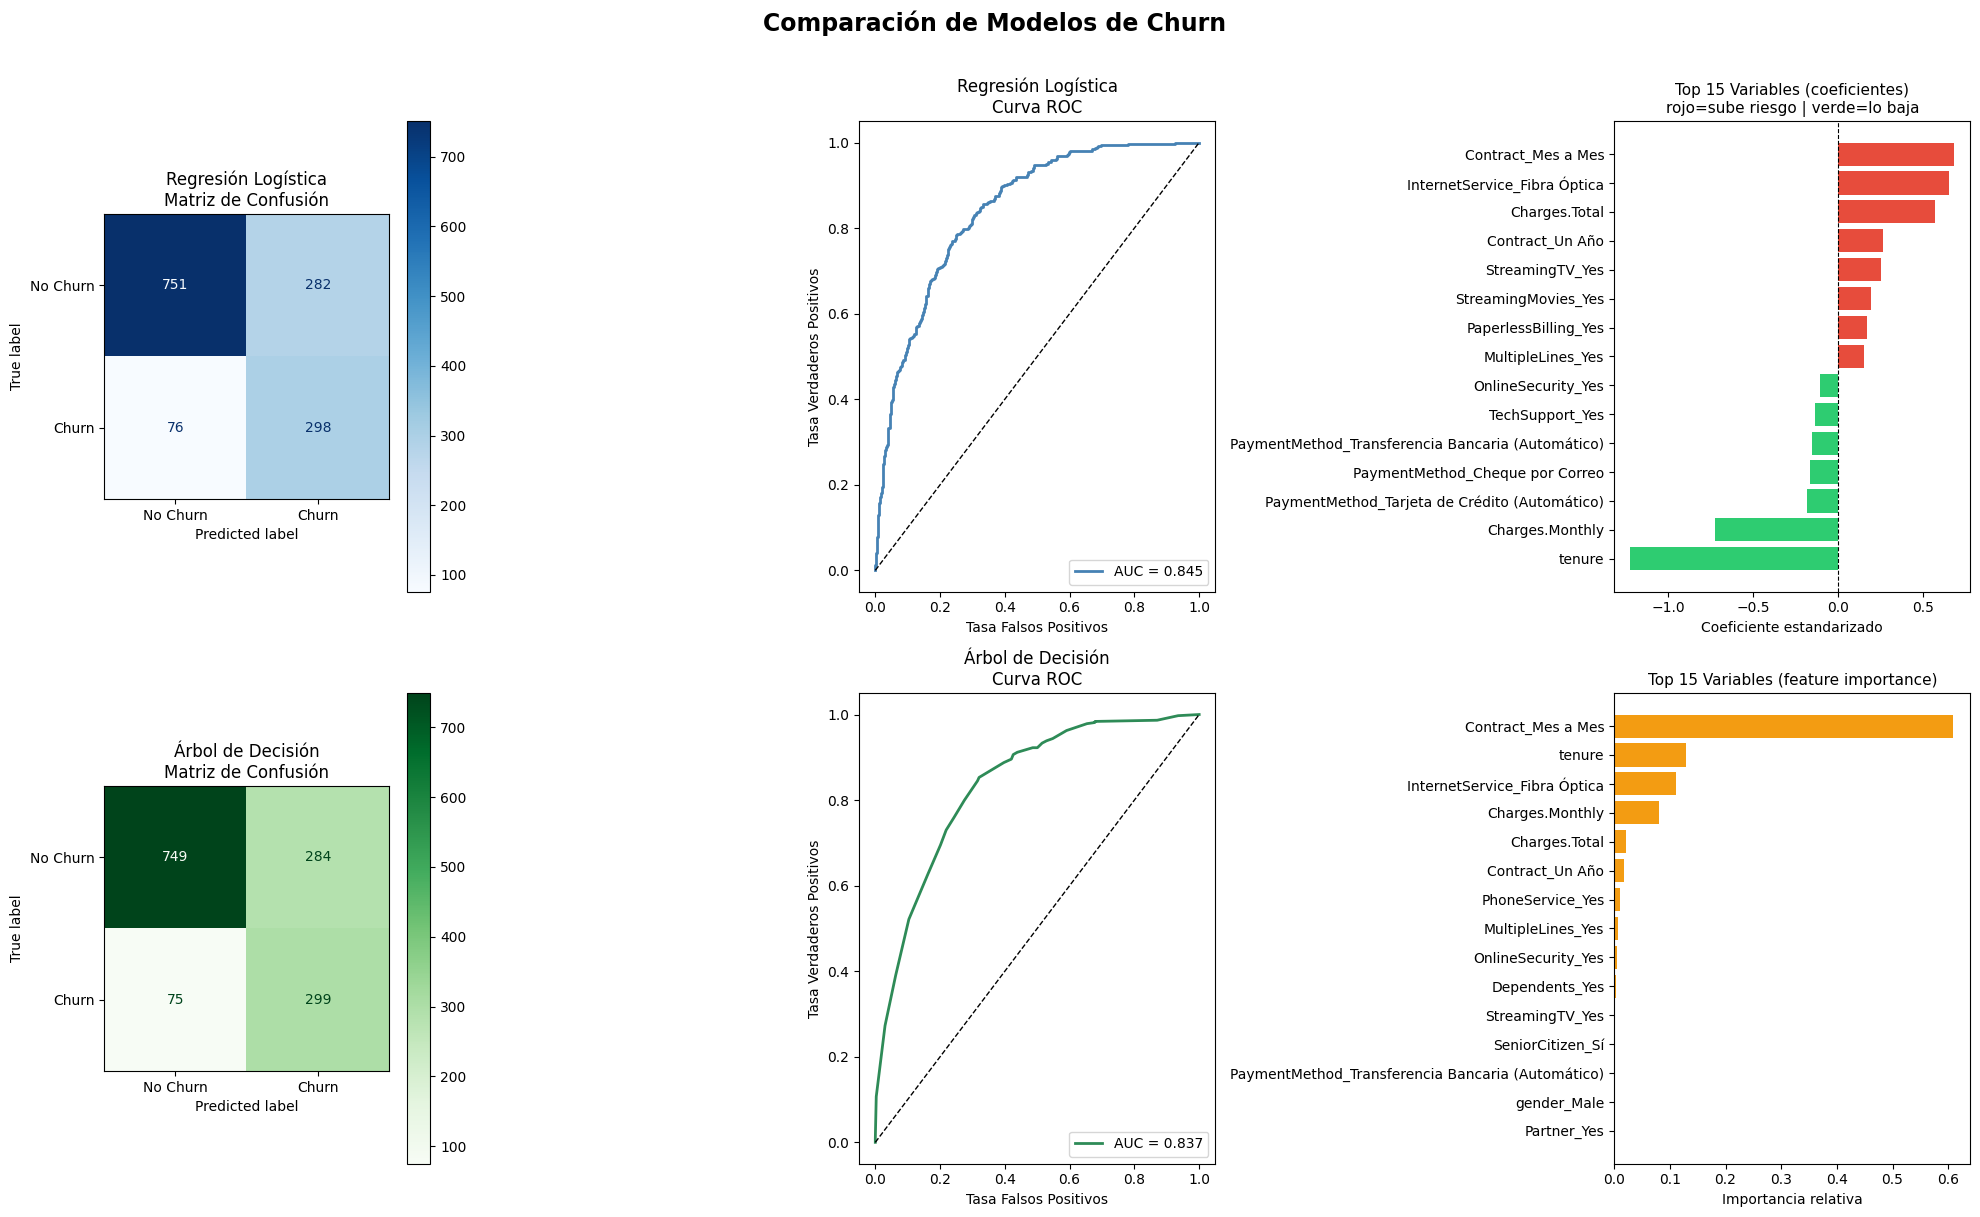


Gráfico comparativo guardado en: churn_comparacion_modelos.png


In [35]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("Comparación de Modelos de Churn", fontsize=17, fontweight='bold', y=1.01)

modelos = [
    ("Regresión Logística", y_pred_rl, y_prob_rl, 'Blues',    'steelblue'),
    ("Árbol de Decisión",   y_pred_dt, y_prob_dt, 'Greens',   'seagreen'),
]

for i, (nombre, y_pred_m, y_prob_m, cmap, color) in enumerate(modelos):

    # Matriz de confusión
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred_m,
        display_labels=['No Churn', 'Churn'],
        cmap=cmap, ax=axes[i][0]
    )
    axes[i][0].set_title(f"{nombre}\nMatriz de Confusión", fontsize=12)

    # Curva ROC
    fpr_m, tpr_m, _ = roc_curve(y_test, y_prob_m)
    axes[i][1].plot(fpr_m, tpr_m, color=color, lw=2,
                    label=f'AUC = {roc_auc_score(y_test, y_prob_m):.3f}')
    axes[i][1].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[i][1].set_xlabel("Tasa Falsos Positivos")
    axes[i][1].set_ylabel("Tasa Verdaderos Positivos")
    axes[i][1].set_title(f"{nombre}\nCurva ROC", fontsize=12)
    axes[i][1].legend(loc='lower right')

    # Variables influyentes
    if nombre == "Regresión Logística":
        coefs = pipeline_rl.named_steps['model'].coef_[0]
        coef_df = pd.DataFrame({'Variable': feature_names, 'Importancia': coefs})
        coef_df['Abs'] = coef_df['Importancia'].abs()
        top_vars = coef_df.nlargest(15, 'Abs').sort_values('Importancia')
        bar_colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in top_vars['Importancia']]
        axes[i][2].barh(top_vars['Variable'], top_vars['Importancia'], color=bar_colors)
        axes[i][2].axvline(0, color='black', linewidth=0.8, linestyle='--')
        axes[i][2].set_title("Top 15 Variables (coeficientes)\nrojo=sube riesgo | verde=lo baja", fontsize=11)
        axes[i][2].set_xlabel("Coeficiente estandarizado")
    else:
        importancias = pipeline_dt.named_steps['model'].feature_importances_
        imp_df = pd.DataFrame({'Variable': feature_names, 'Importancia': importancias})
        top_imp = imp_df.nlargest(15, 'Importancia').sort_values('Importancia')
        axes[i][2].barh(top_imp['Variable'], top_imp['Importancia'], color='#f39c12')
        axes[i][2].set_title("Top 15 Variables (feature importance)", fontsize=11)
        axes[i][2].set_xlabel("Importancia relativa")

plt.tight_layout()
plt.savefig("churn_comparacion_modelos.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nGráfico comparativo guardado en: churn_comparacion_modelos.png")

## Curvas ROC superpuestas para comparación directa

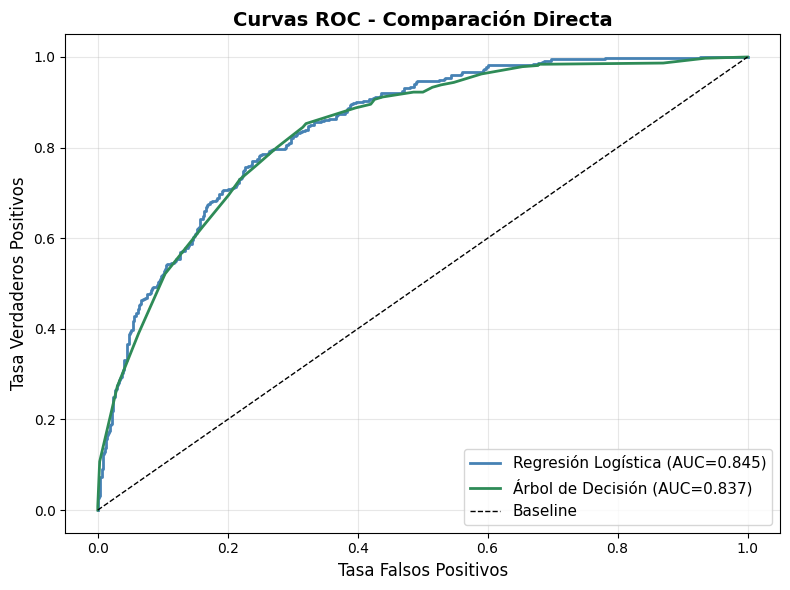

Curvas ROC superpuestas guardadas en: churn_roc_comparacion.png


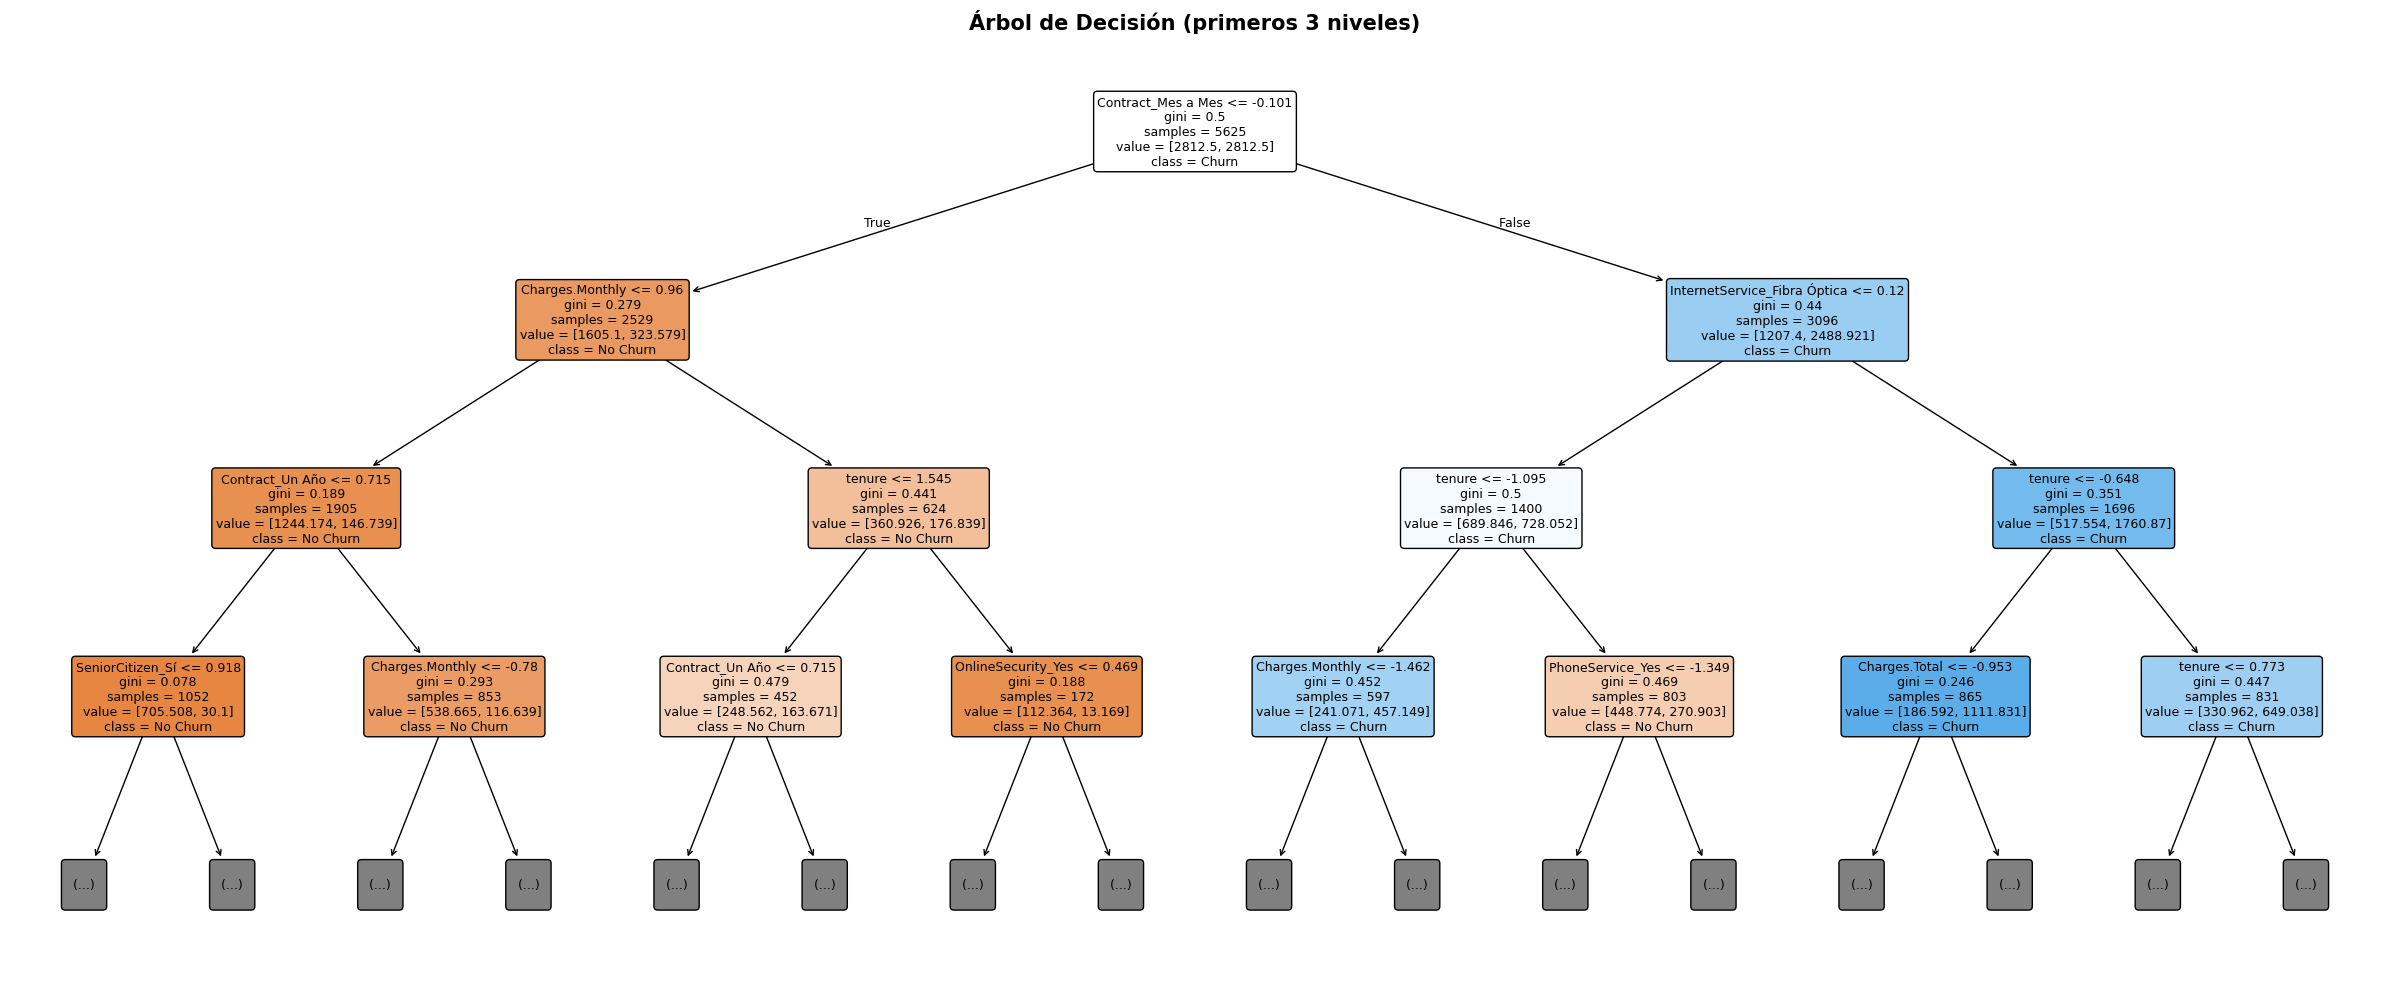

Árbol de decisión guardado en: churn_arbol_decision.png


In [36]:
fig2, ax = plt.subplots(figsize=(8, 6))
for nombre, y_pred_m, y_prob_m, _, color in modelos:
    fpr_m, tpr_m, _ = roc_curve(y_test, y_prob_m)
    ax.plot(fpr_m, tpr_m, color=color, lw=2,
            label=f'{nombre} (AUC={roc_auc_score(y_test, y_prob_m):.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Baseline')
ax.set_xlabel("Tasa Falsos Positivos", fontsize=12)
ax.set_ylabel("Tasa Verdaderos Positivos", fontsize=12)
ax.set_title("Curvas ROC - Comparación Directa", fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("churn_roc_comparacion.png", dpi=150, bbox_inches='tight')
plt.show()
print("Curvas ROC superpuestas guardadas en: churn_roc_comparacion.png")

# --- 7.3 Árbol de decisión visual (profundidad 3 para legibilidad) ---
fig3, ax3 = plt.subplots(figsize=(24, 10))
plot_tree(
    pipeline_dt.named_steps['model'],
    feature_names=feature_names,
    class_names=['No Churn', 'Churn'],
    filled=True, rounded=True,
    max_depth=3,           # Solo mostrar primeros 3 niveles para claridad
    fontsize=9,
    ax=ax3
)
ax3.set_title("Árbol de Decisión (primeros 3 niveles)", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("churn_arbol_decision.png", dpi=120, bbox_inches='tight')
plt.show()
print("Árbol de decisión guardado en: churn_arbol_decision.png")

# Conclusión

In [37]:
from IPython.display import display, Markdown

In [38]:
X_test_resultado = X_test.copy()
X_test_resultado['prob_churn_rl'] = y_prob_rl
X_test_resultado['prob_churn_dt'] = y_prob_dt
X_test_resultado['prob_promedio']  = (y_prob_rl + y_prob_dt) / 2
X_test_resultado['churn_real']     = y_test.values
X_test_resultado['riesgo'] = pd.cut(
    X_test_resultado['prob_promedio'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Bajo', 'Medio', 'Alto']
)

coefs_rl = pipeline_rl.named_steps['model'].coef_[0]
coef_df  = pd.DataFrame({'Variable': feature_names, 'Coeficiente': coefs_rl})
imp_dt   = pipeline_dt.named_steps['model'].feature_importances_
imp_df   = pd.DataFrame({'Variable': feature_names, 'Importancia': imp_dt})

top_rl = set(coef_df.reindex(coef_df['Coeficiente'].abs().nlargest(10).index)['Variable'])
top_dt = set(imp_df.nlargest(10, 'Importancia')['Variable'])
coincidentes = sorted(top_rl & top_dt)
coincidentes_md = "\n".join(f"- `{v}`" for v in coincidentes)

dist_riesgo = X_test_resultado['riesgo'].value_counts().to_string()

## Pregunta 1: ¿Quiénes son los clientes con mayor riesgo de evasión?

Ambos modelos coinciden en que el cliente de **mayor riesgo** es aquel con:
- contrato **mes a mes**
- poco tiempo como cliente (**tenure bajo**)
- servicio de **Fibra Óptica**

Esta combinación es la señal más fuerte detectada por la Regresión Logística (AUC **0.8446**) y el Árbol de Decisión (AUC **0.8367**).

> El **Recall de Churn ≈ 0.80** en ambos modelos indica que **4 de cada 5 clientes** que realmente van a irse son identificados correctamente. El 20% restante escapa sin ser detectado.

**Distribución de riesgo en el conjunto de prueba:**
```
{{dist_riesgo}}
```

In [39]:
display(X_test_resultado.nlargest(10, 'prob_promedio')[
    ['prob_churn_rl', 'prob_churn_dt', 'prob_promedio', 'riesgo']
].style.set_caption("🔴 Top 10 clientes con mayor probabilidad de fuga (prob. promedio)")
 .format({'prob_churn_rl': '{:.3f}', 'prob_churn_dt': '{:.3f}', 'prob_promedio': '{:.3f}'})
 .background_gradient(subset=['prob_promedio'], cmap='Reds'))

,prob_churn_rl,prob_churn_dt,prob_promedio,riesgo
1718,0.885,1.000,0.942,Alto
5429,0.867,1.000,0.934,Alto
2798,0.926,0.926,0.926,Alto
2715,0.852,1.000,0.926,Alto
5778,0.924,0.926,0.925,Alto
3456,0.922,0.926,0.924,Alto
4617,0.913,0.926,0.920,Alto
3845,0.911,0.926,0.919,Alto
64,0.907,0.926,0.916,Alto
5707,0.892,0.926,0.909,Alto


## Pregunta 2: ¿Qué variables influyen más en el comportamiento de churn?
Factores que **DISPARAN** el riesgo *(coeficiente positivo en RL)*

| Variable | Interpretación |
|---|---|
| `Contract_Mes a Mes` | Factor más crítico en ambos modelos. Sin contrato fijo, el cliente puede irse en cualquier momento. |
| `InternetService_Fibra Óptica` | Clientes de Fibra se van más, posiblemente por expectativas de calidad no cumplidas o mayor competencia. |
| `Charges.Total` | A mayor acumulado de pagos sin fidelización percibida, mayor frustración y riesgo de fuga. |
| `PaperlessBilling_Yes` | Perfil 100% digital, sin fricción para cancelar. |
| `StreamingTV_Yes` / `StreamingMovies_Yes` | Cliente activo pero sin compromiso contractual → alta movilidad. |

Factores que **PROTEGEN** y retienen *(coeficiente negativo en RL)*

| Variable | Interpretación |
|---|---|
| `tenure` | A más tiempo como cliente, menor probabilidad de irse. La fidelidad se construye con el tiempo. |
| `Charges.Monthly` | Cargos mensuales altos con contratos largos retienen al cliente (ya invirtió, tiene más que perder). |
| `TechSupport_Yes` | Soporte activo baja el riesgo: el cliente se siente acompañado y percibe más valor. |
| `OnlineSecurity_Yes` | Idem: servicio de valor añadido que genera dependencia positiva. |
| `PaymentMethod_Tarjeta Crédito (Automático)` | El pago automático reduce la fricción de cancelación y genera inercia de permanencia. |




In [41]:
display(Markdown("""
---
## ❓ Pregunta 3: ¿Qué perfil necesita que la empresa se mantenga más cerca?

Ambos modelos construyen el **mismo perfil de riesgo crítico**.

### 🚨 Perfil de Alto Riesgo — *"Cliente Digital Sin Ancla"*

| Dimensión | Característica de riesgo |
|---|---|
| Contrato | Mes a mes *(sin compromiso a largo plazo)* |
| Servicio | Fibra Óptica *(expectativas altas, mayor movilidad)* |
| Antigüedad | tenure < 12 meses *(aún no fidelizado)* |
| Soporte | Sin `TechSupport` ni `OnlineSecurity` activos |
| Facturación | `PaperlessBilling` activo *(perfil 100% digital)* |
| Pago | No automático *(cheque electrónico o manual)* |
| Demografía | Senior Citizen sin pareja ni dependientes |

### 📋 Acciones recomendadas por segmento

| Probabilidad de churn | Acción |
|---|---|
| **> 0.80** | 🔴 **Intervención inmediata:** llamada personal, oferta de migración a contrato anual con descuento o beneficios adicionales. |
| **0.60 – 0.80** | 🟠 **Campaña de valor:** activar `TechSupport` o `OnlineSecurity` gratuito por 3 meses. Migrar a pago automático con incentivo. |
| **0.30 – 0.60** | 🟡 **Monitoreo preventivo:** encuesta de satisfacción + newsletter de beneficios. |

### 💡 Insight clave de los modelos

Con **Recall ≈ 0.80** y **Precision ≈ 0.51** en Churn, los modelos están calibrados para **no perder clientes en riesgo real** (prioridad de negocio), a costa de algunos falsos positivos — clientes que no iban a irse pero reciben atención igualmente, lo cual no es necesariamente malo desde la perspectiva de retención.
"""))


---
## ❓ Pregunta 3: ¿Qué perfil necesita que la empresa se mantenga más cerca?

Ambos modelos construyen el **mismo perfil de riesgo crítico**.

### 🚨 Perfil de Alto Riesgo — *"Cliente Digital Sin Ancla"*

| Dimensión | Característica de riesgo |
|---|---|
| Contrato | Mes a mes *(sin compromiso a largo plazo)* |
| Servicio | Fibra Óptica *(expectativas altas, mayor movilidad)* |
| Antigüedad | tenure < 12 meses *(aún no fidelizado)* |
| Soporte | Sin `TechSupport` ni `OnlineSecurity` activos |
| Facturación | `PaperlessBilling` activo *(perfil 100% digital)* |
| Pago | No automático *(cheque electrónico o manual)* |
| Demografía | Senior Citizen sin pareja ni dependientes |

### 📋 Acciones recomendadas por segmento

| Probabilidad de churn | Acción |
|---|---|
| **> 0.80** | 🔴 **Intervención inmediata:** llamada personal, oferta de migración a contrato anual con descuento o beneficios adicionales. |
| **0.60 – 0.80** | 🟠 **Campaña de valor:** activar `TechSupport` o `OnlineSecurity` gratuito por 3 meses. Migrar a pago automático con incentivo. |
| **0.30 – 0.60** | 🟡 **Monitoreo preventivo:** encuesta de satisfacción + newsletter de beneficios. |

### 💡 Insight clave de los modelos

Con **Recall ≈ 0.80** y **Precision ≈ 0.51** en Churn, los modelos están calibrados para **no perder clientes en riesgo real** (prioridad de negocio), a costa de algunos falsos positivos — clientes que no iban a irse pero reciben atención igualmente, lo cual no es necesariamente malo desde la perspectiva de retención.
